In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('./data/cloud_workload_dataset.csv')

In [3]:
df.head()

,Job_ID,Task_Start_Time,Task_End_Time,CPU_Utilization (%),Memory_Consumption (MB),Task_Execution_Time (ms),System_Throughput (tasks/sec),Task_Waiting_Time (ms),Data_Source,Number_of_Active_Users,Network_Bandwidth_Utilization (Mbps),Job_Priority,Scheduler_Type,Resource_Allocation_Type,Error_Rate (%)
0,JOB_1,2024-01-01 00:00:00,2024-01-01 00:00:00,39.96,3622,2734,9.03,83,IoT,3000,112.97,Low,FCFS,Static,1.65
1,JOB_2,2024-01-01 00:01:00,2024-01-01 00:01:00,86.06,5690,2868,8.03,64,Social Media,4590,329.20,Low,Priority-Based,Dynamic,2.92
2,JOB_3,2024-01-01 00:02:00,2024-01-01 00:02:00,68.56,5075,1311,5.69,971,Cloud,3780,542.82,Low,Priority-Based,Static,2.60
3,JOB_4,2024-01-01 00:03:00,2024-01-01 00:03:00,57.89,7686,875,4.51,757,Social Media,4474,973.94,Medium,Priority-Based,Dynamic,1.33
4,JOB_5,2024-01-01 00:04:00,2024-01-01 00:04:00,22.48,2297,1260,6.38,581,Enterprise DB,1981,405.38,Low,FCFS,Static,1.99


In [5]:
df['Task_Start_Time'] = pd.to_datetime(df['Task_Start_Time'])
df['hour'] = df['Task_Start_Time'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

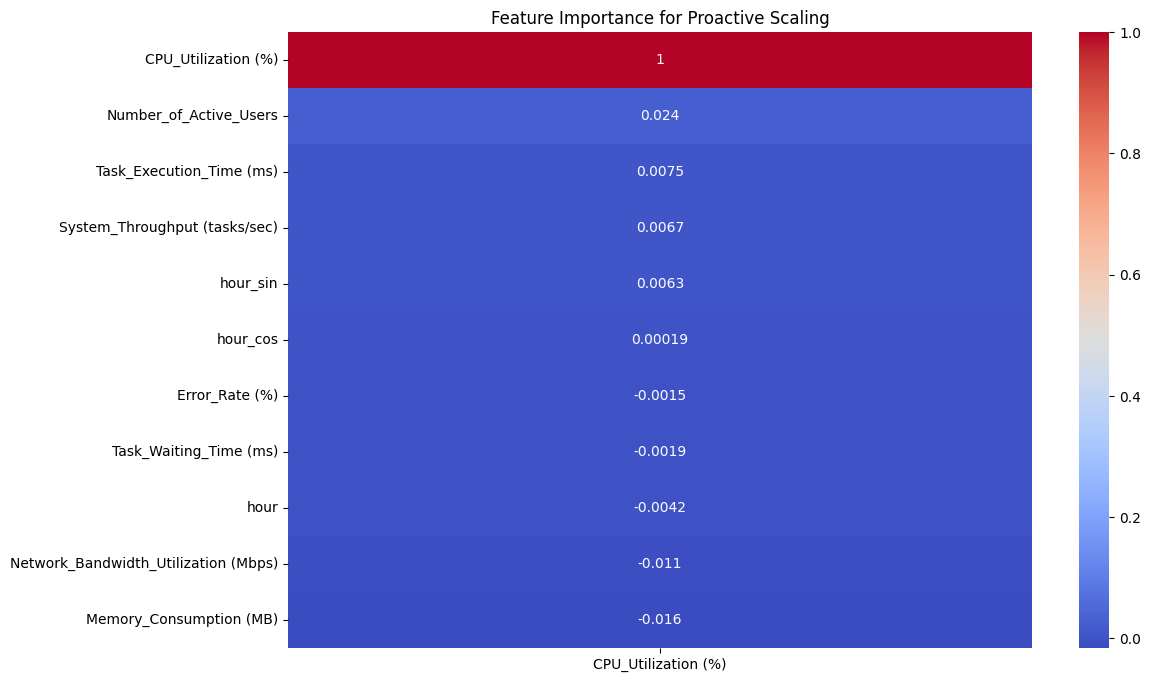

In [6]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix[['CPU_Utilization (%)']].sort_values(by='CPU_Utilization (%)', ascending=False), 
            annot=True, cmap='coolwarm')
plt.title("Feature Importance for Proactive Scaling")
plt.show()

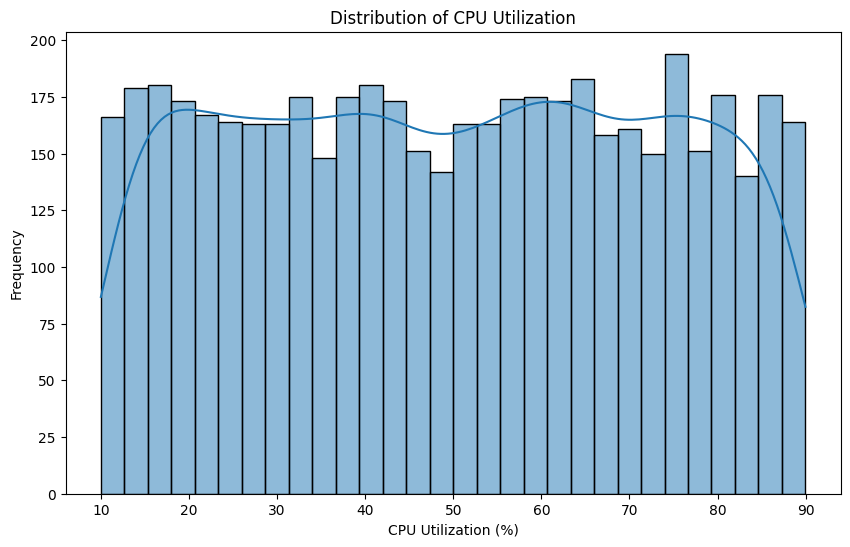

In [ ]:
# Distribution of the CPU utilisation
plt.figure(figsize=(10, 6))
sns.histplot(df['CPU_Utilization (%)'], bins=30, kde=True) # type: ignore
plt.title("Distribution of CPU Utilization")
plt.xlabel("CPU Utilization (%)")
plt.ylabel("Frequency")
plt.show()

In [7]:
# Label encoding for categorical columns
priority_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}
df['Job_Priority'] = df['Job_Priority'].map(priority_map)

# One-hot encoding for categorical columns
cat_cols = ['Scheduler_Type', 'Resource_Allocation_Type']
df = pd.get_dummies(df, columns=cat_cols)

In [27]:
df.head()

,Job_ID,Task_Start_Time,Task_End_Time,CPU_Utilization (%),Memory_Consumption (MB),Task_Execution_Time (ms),System_Throughput (tasks/sec),Task_Waiting_Time (ms),Data_Source,Number_of_Active_Users,Network_Bandwidth_Utilization (Mbps),Job_Priority,Error_Rate (%),hour,hour_sin,hour_cos,Scheduler_Type_ASB-Dynamic-CapsNet,Scheduler_Type_FCFS,Scheduler_Type_Priority-Based,Scheduler_Type_Round Robin,Resource_Allocation_Type_Dynamic,Resource_Allocation_Type_Static
0,JOB_1,2024-01-01 00:00:00,2024-01-01 00:00:00,39.96,3622,2734,9.03,83,IoT,3000,112.97,0,1.65,0,0.0,1.0,False,True,False,False,False,True
1,JOB_2,2024-01-01 00:01:00,2024-01-01 00:01:00,86.06,5690,2868,8.03,64,Social Media,4590,329.20,0,2.92,0,0.0,1.0,False,False,True,False,True,False
2,JOB_3,2024-01-01 00:02:00,2024-01-01 00:02:00,68.56,5075,1311,5.69,971,Cloud,3780,542.82,0,2.60,0,0.0,1.0,False,False,True,False,False,True
3,JOB_4,2024-01-01 00:03:00,2024-01-01 00:03:00,57.89,7686,875,4.51,757,Social Media,4474,973.94,1,1.33,0,0.0,1.0,False,False,True,False,True,False
4,JOB_5,2024-01-01 00:04:00,2024-01-01 00:04:00,22.48,2297,1260,6.38,581,Enterprise DB,1981,405.38,0,1.99,0,0.0,1.0,False,True,False,False,False,True


In [8]:
cols_to_drop = ['Job_ID', 'Task_Start_Time', 'Task_End_Time', 'Data_Source']
df_cleaned = df.drop(columns=cols_to_drop)

In [9]:
df_cleaned.columns

Index(['CPU_Utilization (%)', 'Memory_Consumption (MB)',
       'Task_Execution_Time (ms)', 'System_Throughput (tasks/sec)',
       'Task_Waiting_Time (ms)', 'Number_of_Active_Users',
       'Network_Bandwidth_Utilization (Mbps)', 'Job_Priority',
       'Error_Rate (%)', 'hour', 'hour_sin', 'hour_cos',
       'Scheduler_Type_ASB-Dynamic-CapsNet', 'Scheduler_Type_FCFS',
       'Scheduler_Type_Priority-Based', 'Scheduler_Type_Round Robin',
       'Resource_Allocation_Type_Dynamic', 'Resource_Allocation_Type_Static'],
      dtype='str')

In [ ]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
  # Convert Task_Start_Time to datetime and extract hour features
  df['Task_Start_Time'] = pd.to_datetime(df['Task_Start_Time'])
  df['hour'] = df['Task_Start_Time'].dt.hour
  df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
  df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
  
  # Label encoding for Job_Priority
  priority_map = {'Low': 0, 'Medium': 1, 'High': 2}
  df['Job_Priority'] = df['Job_Priority'].map(priority_map)
  
  # One-hot encoding for categorical columns
  cat_cols = ['Scheduler_Type', 'Resource_Allocation_Type']
  df = pd.get_dummies(df, columns=cat_cols)
  
  # Drop unnecessary columns
  cols_to_drop = ['Job_ID', 'Task_Start_Time', 'Task_End_Time', 'Data_Source']
  df_cleaned = df.drop(columns=cols_to_drop)
  
  return df_cleaned

In [10]:
# Defining features and target
X = df_cleaned.drop('CPU_Utilization (%)', axis=1)
y = df_cleaned['CPU_Utilization (%)']

# Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale (Standardize)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


# Model Implementation

In [11]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

In [12]:
# Initialize the model
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)

# Fit the model
sgd_model.fit(X_train_scaled, y_train)

# Predict values
y_pred = sgd_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
print(f"Model 1 (SGD) Mean Squared Error: {mse:.4f}")

Model 1 (SGD) Mean Squared Error: 535.6783


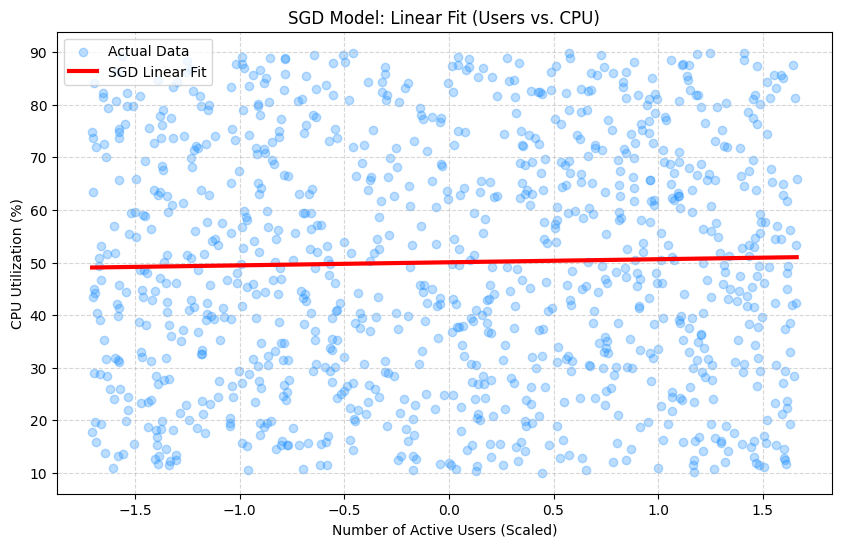

In [14]:
feature_idx = X.columns.get_loc('Number_of_Active_Users')
X_test_feature = X_test_scaled[:, feature_idx]

m = sgd_model.coef_[feature_idx]
b = sgd_model.intercept_

x_line = np.linspace(X_test_feature.min(), X_test_feature.max(), 100)
y_line = m * x_line + b

plt.figure(figsize=(10, 6))
plt.scatter(X_test_feature, y_test, color='dodgerblue', alpha=0.3, label='Actual Data')
plt.plot(x_line, y_line, color='red', linewidth=3, label='SGD Linear Fit')
plt.title('SGD Model: Linear Fit (Users vs. CPU)')
plt.xlabel('Number of Active Users (Scaled)')
plt.ylabel('CPU Utilization (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [33]:
# Random Forest Model

In [34]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"Model 1 (SGD) MSE: {mse:.4f}")
print(f"Model 2 (Random Forest) MSE: {mse_rf:.4f}")

Model 1 (SGD) MSE: 535.6783
Model 2 (Random Forest) MSE: 538.0610


In [38]:
# Decision Tree Model

In [39]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [53]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
mse_dt = mean_squared_error(y_test, y_pred_dt)

print(f"Model 1 (SGD) MSE: {mse:.4f}")
print(f"Model 2 (Random Forest) MSE: {mse_rf:.4f}")
print(f'Model 3 (Decision Tree) MSE: {mse_dt:.4f}')

Model 1 (SGD) MSE: 535.6783
Model 2 (Random Forest) MSE: 538.0610
Model 3 (Decision Tree) MSE: 532.7734


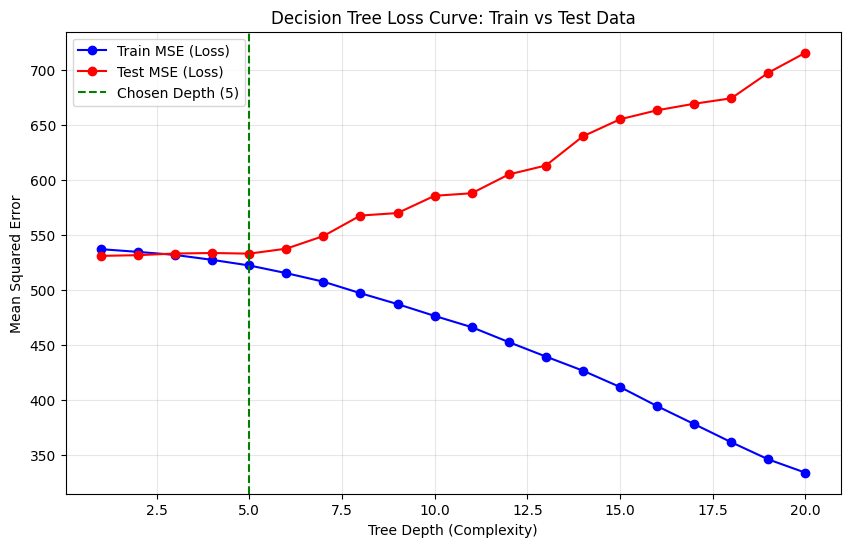

In [62]:
depths = range(1, 21)
train_mse = []
test_mse = []

# Loop through depths to capture "Loss"
for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    # Training Loss
    train_pred = dt.predict(X_train_scaled)
    train_mse.append(mean_squared_error(y_train, train_pred))
    
    # Testing Loss
    test_pred = dt.predict(X_test_scaled)
    test_mse.append(mean_squared_error(y_test, test_pred))

# Plotting the Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(depths, train_mse, label='Train MSE (Loss)', color='blue', marker='o')
plt.plot(depths, test_mse, label='Test MSE (Loss)', color='red', marker='o')

# Highlighting the chosen depth
plt.axvline(x=5, color='green', linestyle='--', label='Chosen Depth (5)')

plt.title('Decision Tree Loss Curve: Train vs Test Data')
plt.xlabel('Tree Depth (Complexity)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

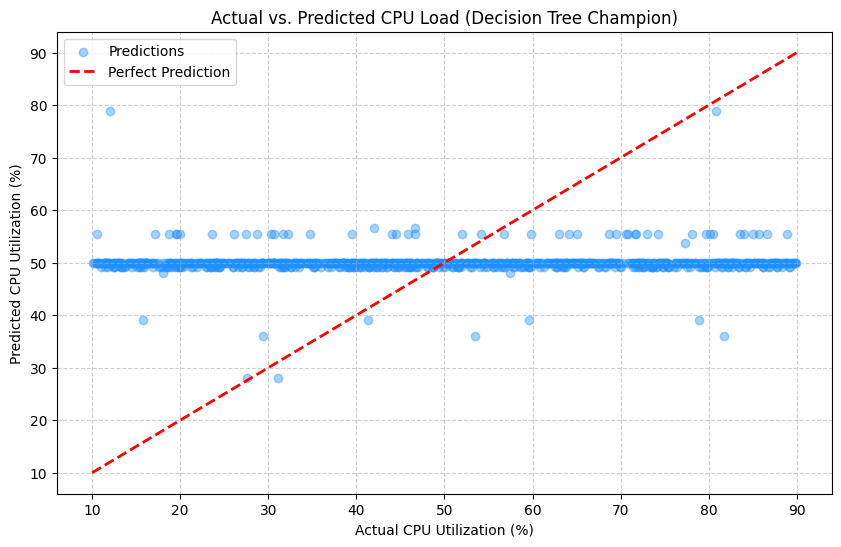

In [54]:
# Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.4, color='dodgerblue', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual CPU Utilization (%)')
plt.ylabel('Predicted CPU Utilization (%)')
plt.title('Actual vs. Predicted CPU Load (Decision Tree Champion)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('actual_vs_predicted.png')

In [56]:
# Saving the Decision Tree model

In [57]:
import pickle

In [59]:
# Save the model
with open('./scaling_model/model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

# Save the scaler
with open('./scaling_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)